In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *
from pathlib import Path 
import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [2]:
NEvents 183102850.0


SyntaxError: invalid syntax (<ipython-input-2-de651f698c3f>, line 1)

# Load ntuples

In [4]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = 'v30'
LUMI_SCALE = 1
# for data_year in ['2022','2023','all']:
for data_year in ['all']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['Signal'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
# fpath['Signal_HV'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v25/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root'
# fpath['sig_tau'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v30/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 182909920.0
Signal /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v30/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 189549180.0
CPU times: user 372 ms, sys: 16.1 ms, total: 388 ms
Wall time: 527 ms


In [5]:
# NEvents 159888100.0
categories = ['inclusive']


# apply selections

In [6]:
%%time

# 0:"no selections"
# 1:"in-time cut": show jet, muon, ME1 veto
# 2: in-time + ME1 veto: show jet, muon
# 3:"+jet/muon/ME1 veto": show DNN, timespread
# 4:"add DNN, time spread, dPhi > 1.8, dR < 3.5 + inverted time cut for 2nd cluster

dir_name = {
    0: "no_selections",
    1: "intime",
    2: "intime_ME1",
    3: "intime_ME1_jetmuonveto",
    4: "data_oot",
}
selections = 2
MUON_PT_CUT = 30
JET_PT_CUT = 30
DNN_CUT = 0.96

cscRechitClusterMe11 = {}
cscRechitClusterMe12 = {}
cscRechitClusterJetVetoPt = {} 
cscRechitClusterGlobalMuonVetoPt = {}
cscRechitClusterMuonVetoPt = {}
cscRechitClusterNStation = {}
cscRechitClusterPhi = {}
cscRechitClusterEta = {}
cscRechitClusterDNN = {}
cscRechitClusterTime = {}
cscRechitClusterTimeSpread = {}
cscRechitClusterSize = {}
deltaPhi_cluster = {}
deltaR_cluster = {}
cscRechitClusterNStationSum = {}
cscRechitClusterMet_dPhi = {}
cscRechitClusterMe1 = {}
nJets = {}
jetPt = {}
met = {}
metPhi = {}
Puppimet = {}
PuppimetPhi = {}
runNum = {}
HMTEff = {}
weight = {}
categories = ['NStation3', 'NStation4']
categories = ['inclusive']
region_list = ['oot', 'signal']
# for region in region_list:
for tree_k in tree.keys():
    T = tree[tree_k]
    for cat in categories:
        # if not region == 'signal': continue
        k = f'{tree_k}_{cat}'


    ########### SELECTION: CLUSTERS ############
        me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
        T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())

#         # cluster = 
#         #one cluster to pass trigger
        if selections >= 0: 
            cluster = (me1 >= 0)                 
        if selections >=1 and selections <=3:
            cluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
        
        if selections>=2: cluster = cluster & (me1 == 0)
        if selections >=3:
            cluster = cluster & (T['cscRechitClusterJetVetoPt'].array() < JET_PT_CUT)
            cluster = cluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > MUON_PT_CUT) & T['cscRechitClusterMuonVetoGlobal'].array())    
        # if selections >=4:
        #     cluster = cluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)

    ########### SELECTION: EVENTS ############
        sel_ev = T['HLT_CSCCSC'].array()
        sel_ev  = np.logical_and(sel_ev,np.sum(cluster, axis = 1) == 2)
        print(np.count_nonzero(sel_ev))
        # if selections >= 4: 
        #     sel_ev = sel_ev & (T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[:,0] >= DNN_CUT)
        #     sel_ev = sel_ev & (T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[:,1] >= DNN_CUT)

        cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
        cluster_pass_HLT = cluster_pass_HLT & (me1==0) & np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
        sel_ev  = np.logical_and(sel_ev,np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
        sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
        sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
        sel_ev = np.logical_and(sel_ev,T['nCscRechitClusters'].array()==2)
        if not "data" in k and not "HV" in k: sel_ev = sel_ev & (np.sum(T['cscRechitCluster_match_gLLP'].array(), axis= 1) == 2)
            

    ########### BRANCHES ############
       ##### event variables ##### 
        cscRechitClusterMe11[k] = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberMinus11'].array())[sel_ev]
        cscRechitClusterMe12[k] = (T['cscRechitClusterNRechitChamberPlus12'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())[sel_ev]
        cscRechitClusterMe1[k] = cscRechitClusterMe11[k] + cscRechitClusterMe12[k]
        cscRechitClusterJetVetoPt[k] = T['cscRechitClusterJetVetoPt'].array()[sel_ev]
        cscRechitClusterGlobalMuonVetoPt[k] = (T['cscRechitClusterMuonVetoPt'].array()*T['cscRechitClusterMuonVetoGlobal'].array())[sel_ev]
        cscRechitClusterMuonVetoPt[k] = T['cscRechitClusterMuonVetoPt'].array()[sel_ev]
        cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()[sel_ev]
        cscRechitClusterNStationSum[k] = np.sum(T['cscRechitClusterNStation10'].array()[sel_ev], axis = 1)
        cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[sel_ev]
        cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[sel_ev]
        cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[sel_ev]
        cscRechitClusterTime[k] = T['cscRechitClusterTimeWeighted'].array()[sel_ev]
        cscRechitClusterTimeSpread[k] = T['cscRechitClusterTimeSpreadWeightedAll'].array()[sel_ev]
        cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[sel_ev]
        deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k][:,0]), np.array(cscRechitClusterPhi[k][:,1]))
        deltaR_cluster[k] = ((cscRechitClusterEta[k][:,0]-cscRechitClusterEta[k][:,1])**2 + deltaPhi_cluster[k]**2)**0.5
        HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[sel_ev]
        met[k] = T['met'].array()[sel_ev]
        metPhi[k] = T['metPhi'].array()[sel_ev]
        Puppimet[k] = T['Puppimet'].array()[sel_ev]
        PuppimetPhi[k] = T['PuppimetPhi'].array()[sel_ev]
        
        sel_jet = np.abs(T['jetEta'].array())<2.4
        nJets[k] = np.sum(sel_jet,axis=1)[sel_ev]
        jetPt[k] = np.max(T['jetPt'].array()[sel_ev], axis = 1)
        cscRechitClusterMet_dPhi[k] = T['cscRechitClusterMet_dPhi'].array()[sel_ev]

        cluster_pass_HLT = cluster_pass_HLT[sel_ev]
        HMTEff[k] = 1-HMTEff[k][cluster_pass_HLT]
        HMTEff[k] = 1-np.prod(HMTEff[k],axis=1)


        if 'data' in k:weight[k] = (T['weight'].array())[sel_ev]*0.0 + 1                                                             
        else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev]*HMTEff[k]*LUMI_SCALE
        print("events in this region:", k, len(deltaPhi_cluster[k]), np.sum(weight[k]), len(weight[k]))

189690
events in this region: dataall_inclusive 175110 175110.0 175110
14072
events in this region: Signal_inclusive 13251 14330.257 13251
CPU times: user 9.32 s, sys: 1.11 s, total: 10.4 s
Wall time: 21 s


In [8]:
variables = {
'cscRechitClusterMe11': ['CSC cluster N_{ME11 hits}', cscRechitClusterMe11, [50,0,50], True],
'cscRechitClusterMe12': ['CSC cluster N_{ME12 hits}', cscRechitClusterMe12, [50,0,50], True],
'cscRechitClusterMe1': ['CSC cluster N_{ME11/12 hits}', cscRechitClusterMe1, [50,0,50], True],
'cscRechitClusterJetVetoPt': ['CSC cluster jet veto p_{T} [GeV]', cscRechitClusterJetVetoPt, [30,0,300], True],
'cscRechitClusterGlobalMuonVetoPt': ['CSC cluster muon veto p_{T} [GeV]', cscRechitClusterGlobalMuonVetoPt, [30,0,300], True],
# 'cscRechitClusterMuonVetoPt': [cscRechitClusterMuonVetoPt, [50,0,500], True],
'cscRechitClusterNStation': ['CSC cluster  N_{stations}', cscRechitClusterNStation, [5,0,5], True],
'cscRechitClusterPhi': ['CSC cluster #phi', cscRechitClusterPhi, [50,-3.5,3.5], True],
'cscRechitClusterEta': ['CSC cluster #eta', cscRechitClusterEta, [50,-3,3], True],
'cscRechitClusterDNN': ['CSC cluster DNN score', cscRechitClusterDNN, [50,0,1], True],
'cscRechitClusterTime': ['CSC cluster time [ns]', cscRechitClusterTime, [50,-100,100], False],
'cscRechitClusterTimeSpread': ['CSC cluster time spread [ns]', cscRechitClusterTimeSpread, [50,0,50], True],
'cscRechitClusterSize': ['CSC cluster N_{hits}', cscRechitClusterSize, [50,0,500], True],
'cscRechitClusterMet_dPhi': ['#Delta#phi(MET, cluster)', cscRechitClusterMet_dPhi, [25,0,3.2], True],
'deltaPhi_cluster': ['#Delta#phi(cluster 1, cluster 2)', deltaPhi_cluster, [25,0,3.2], True],
'deltaR_cluster': ['#Delta R(cluster 1, cluster 2)', deltaR_cluster, [50,0,5], True],
'cscRechitClusterNStationSum': ['sum of N_{stations}', cscRechitClusterNStationSum, [10,0,10],True],
'nJets':['Number of jets', nJets, [10,0,10],True],
'jetPt':['jet pT [GeV]', jetPt, [50,0,200],True],
"met": ['MET [GeV]', met, [50,0,200],True],
"metPhi": ['MET #phi [rad]', metPhi, [50,-3.2,3.2],True],
"Puppimet": ['MET [GeV]', Puppimet, [50,0,200],True],
"PuppimetPhi": ['MET #phi [rad]', PuppimetPhi, [50,-3.2,3.2],False],

}
plot_dir = GIT_REPO + f"/plots/selections_csccsc_{dir_name[selections]}/"
Path(plot_dir).mkdir(parents=True, exist_ok=True)

# Plot Distributions

dataall_inclusive 140863.0
Signal_inclusive 14295.5625
dataall_inclusive 140863.0
Signal_inclusive 14295.5625
0.032582998275756836


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


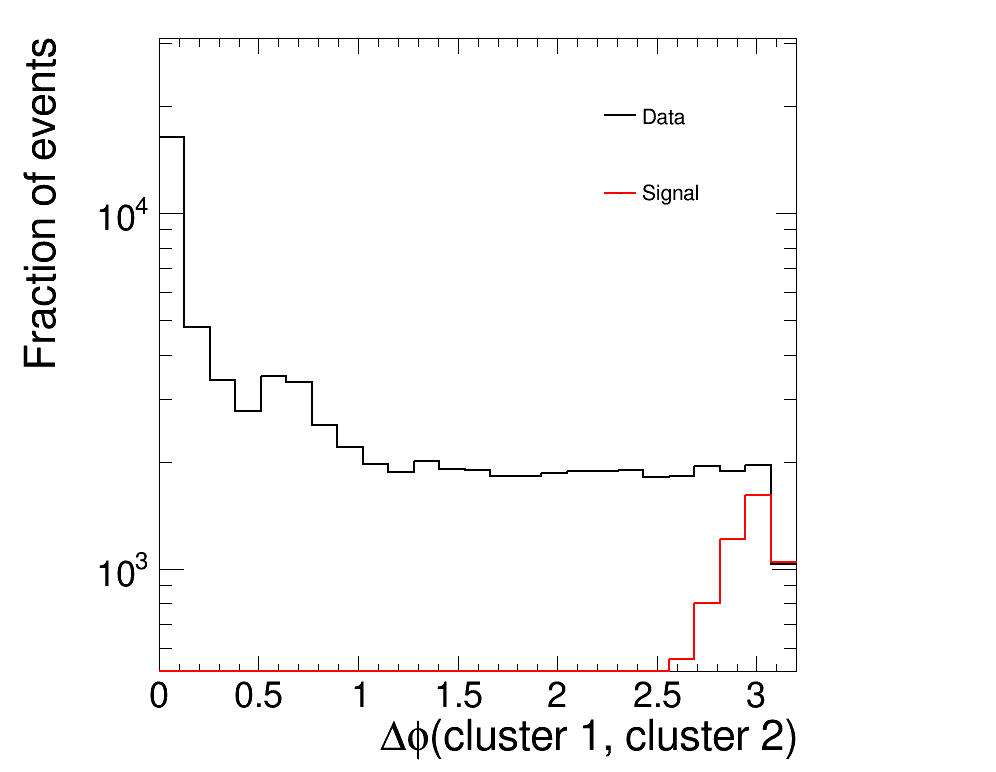

In [12]:
# Plotting ncsc
start_t = time.time()
for cluster_i in [0,1]:
    for name, v in variables.items():
        # if not "Size" in name:continue
        if not "deltaPhi_cluster" in name:continue
        c = rt.TCanvas('c','c', 1000, 800)
        h = {}
        if selections == 4:leg = rt.TLegend(0.5,0.7,0.78,0.9)
        else: leg = rt.TLegend(0.6,0.7,0.78,0.9)
        leg.SetTextSize(0.03)
        leg.SetTextFont(42)
        leg.SetBorderSize(0)
        xaxis, plot_var, bins, logy = v
        i = 0
        for k in plot_var.keys():
            
            if 'invertDNN_sig' in k or 'oot_sig' in k:continue
            cond = np.abs(deltaPhi_cluster[k])>=0.4
            if "data" in k and selections <4 :cond = cscRechitClusterSize[k][:,1]<100
            if selections == 4:
                if "data" in k:cond = cscRechitClusterTime[k][:,1] < -12.5
                else:cluster = (cscRechitClusterTime[k][:,1] > -5) & (cscRechitClusterTime[k][:,1] < 12.5)
            
            if "jetPt" in name: cond = cond & (nJets[k]>0)
            print(k, np.sum(weight[k][cond]))
            # continue
            if plot_var[k].ndim == 1:
                h[k] = create_TH1D( np.array(plot_var[k][cond]), axis_title = [xaxis,'Fraction of events'], binning=bins,weights = np.array(weight[k][cond]))
            else:
                h[k] = create_TH1D( np.array(plot_var[k][cond][:,cluster_i]), axis_title = [xaxis,'Fraction of events'], binning=bins,weights = np.array(weight[k][cond]))

            # if h[k].Integral()>0: h[k].Scale(1./h[k].Integral())
            # if logy: h[k].SetMaximum(10)
            # else: h[k].SetMaximum(1)
            # if "Puppi" in name: h[k].SetMinimum(1e-5)
            # else: h[k].SetMinimum(7e-4)
            # print(np.count_nonzero(np.array(plot_var[k][cond])>0)/len(np.array(plot_var[k][cond])))
            h[k].SetLineColor(std_color_list[i])
            if "data" in k and selections >= 4:leg.AddEntry(h[k],'Data (2nd cluster OOT)')
            elif "data" in k: leg.AddEntry(h[k],'Data')
            else: leg.AddEntry(h[k],k.replace('_inclusive',''))
            h[k].Draw('hist same')
            i+=1
        c.SetRightMargin(0.2)

        if logy: c.SetLogy()
        leg.Draw()
        c.Draw()

        # c.SaveAs(plot_dir + f"/{name}_{cluster_i}.png")
        # c.SaveAs(plot_dir + f"/{name}_{cluster_i}.pdf")
        # c.SaveAs(plot_dir + f"/{name}_{cluster_i}.C")
        # break


print(time.time()-start_t)
